In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
#%pip install handcalcs

In [3]:
from handcalcs import *
from handcalcs import render
import handcalcs

In [4]:
def trigger (sig , thresh= None, transition= "rise", marginI = 20):
    arr=[0]
    if thresh is None: 
        thresh = (sig.max()+sig.min())/2
    for i in range(1, len(sig)):
        if transition =="rise":
            if sig[i-1] <thresh and sig[i] >= thresh and i > arr[-1]+marginI:
                arr.append(i)
        elif sig[i-1] >thresh and sig[i] <= thresh and i > arr[-1]+marginI:
            arr.append(i)
    return arr[1:]


In [5]:
# Initialization 
bl= '#1520c0' # blue 
rd= '#C62828' # red
fig_counter=1

In [6]:
# CONFIGURATIONS
#help(handcalcs.set_option)
handcalcs.set_option("latex_block_start", "$")
handcalcs.set_option("latex_block_end", "$")
handcalcs.set_option("math_environment_end", "aligned")
handcalcs.set_option("use_scientific_notation",True)

In [7]:
#from figModel import *
from figModelv2 import *

In [8]:
_='''

fig_counter=  show_figure_pair_with_captions(fig_counter, 
                         img1="figs/jlc_details.png" , 
                         caption1="JLC-configuration of this PCB",
                         first_part_path="", width="100%")


fig_counter= show_figure_pair_with_captions(
    fig_counter, 
    img1="meas3.png", 
    caption1="One inner layer", 
    img2="meas5.png",
    caption2="2 outer layers", 
    first_part_path="figs/")
    
    
    '''






<h1 align="center"> Gate driver and double pulse tests</h1>

<br><br><br><br><br><br><br>
<div align="center">
  <img align="center" src = "figs/gateDriverAndDoublePulseTests.png">  
</div>

## Table of contents

## Primary driver

In [9]:
s1= "Mosfet gate driver and double pulse tests"

# Split the snake_case string into a list of words
s2 = s1.split(' ')

# Capitalize each word after the first and join them back together
res = s2[0] + ''.join(word.capitalize() for word in s2[1:])
print(res)

MosfetGateDriverAndDoublePulseTests


In [10]:
fig_counter=  show_figure_pair_with_captions(
fig_counter, 
img1="Schem.png", 
caption1="Reminder of the primary gate driver sub-schematic: Final version", 
first_part_path="./figs/", 
width="100%"
)

### Driver HW dead time

Let's check the accuracy of the programmed (HW) dead time of the used driver

No SW dead time was programmed, the dead time is managed ONLY by thr RT = 11.5kohm 


<u> Oscilloscope:</u> <br> 
* **CH1** : INA
* **CH2** : INB
* **CH3** : OUTA
* **CH4** : OUTB

<u> Driver:</u> <br> 
**ucc21520Q**
<br>
<br> <u> Programmed dead time </u><br>
RT = 11.5k, so dead time = 115ns

In [11]:
fig_counter=show_figure_pair_with_captions(fig_counter, 
                               img1="s1.png", 
                               caption1="Zoom out to see 2 periods, 100khz", 
                               img2="s2.png", 
                               caption2="Zoom in around the dead time: DT=126ns", 
                               first_part_path="01_driver_no_sw_dead_time/")



In [12]:

fig_counter=show_figure_pair_with_captions(fig_counter, 
                               img1="s1.png", 
                               caption1="Zoom out to see 2 periods, 100khz", 
                               img2="s3.png", 
                               caption2="Zoom in around the dead time: DT=116ns", 
                               first_part_path="01_driver_no_sw_dead_time/")



In [13]:
%%render 2
DT_Prog = 115 # ns
DT_Meas = 116 # ns
Error =  100*(DT_Meas-DT_Prog)/DT_Prog # \%

<IPython.core.display.Latex object>

So the mesured dead time is very accurate

### Bootstrap circuit

Lest's check the bootstrap circuit (DRC) 

**SINGLE pulse**

In this test, the low-side MOSFET is driven by a single long pulse.

Peak current estimation : 

In [14]:
%%render 
V12=12# V
Vd= 0.7 #V
Rboot =2.15
Iboot = (V12-Vd)/Rboot

<IPython.core.display.Latex object>

In [15]:



fig_counter=  show_figure_pair_with_captions(
fig_counter, 
                         img1="2025-12-01_16-48-34-151.png", 
                         caption1="Bootstrap circuit measurement with 10us pulse width", 
                         first_part_path="./04_boostramp_capa/OnePulse10us/", 
width="75%"
)

Oscilloscope:<br> 
* **CH1** : bootstrap capacitor voltage
* **CH2** : bootstrap diode current
* **CH4** : Vgs low side MOSFET

Peak current measurement : 

$ I_{bootMeasure} $ ~ **3.8 Apeak**

The measured peak current is lower than the estimated value because the estimate was based on the assumption that the only resistance in the path was the 2.15-ohm resistor, which represents a pessimistic (worst-case) assumption.

Below is a fast/simplified reproduction of this test in simulation

In [16]:
fig_counter=  show_figure_pair_with_captions(
fig_counter, 
img1="boot2.png", 
caption1="Quick simulation of the bootstrap circuit with 10us pulse width", 
first_part_path="./04_boostramp_capa/sim/", 
width="75%"
)

In [17]:
#file = "./04_boostramp_capa/OnePulse10us/2025-12-01_16-48-34-151.csv"
#dfb = pd.read_csv(file)

**PWM mode**

In this test, the low-side MOSFET is driven by a pulse train with frequency of 100kHz (more realistic).

In [18]:
file = "2025-12-01_17-40-57-756.csv"
folder = "./04_boostramp_capa/PWM100kHz/"

In [19]:
fig_counter=  show_figure_pair_with_captions(
fig_counter, 
 img1=file.replace(".csv",".png"), 
 caption1="Bootstrap circuit measurement with PWM 100kHz 50% duty cycle", 
 first_part_path=folder, 
width="75%"
)

Below is a fast/simplified reproduction of this test in simulation

In [20]:
fig_counter=  show_figure_pair_with_captions(
fig_counter, 
img1="boot3.png", 
caption1="Quick simulation of the bootstrap circuit 100kHz 50% duty cycle", 
first_part_path="./04_boostramp_capa/sim/", 
width="75%"
)

Estimation of the charge time of the bootstrap capacitor: 

In [21]:
%%render 
C=1  # µs
R= 2.15 # ohm
To = R*C # µs


<IPython.core.display.Latex object>

3 corresponds to the 99% level, and 2 represents the 50% duty cycle.

In [22]:
%%render 
time = To*5*2 # µs

<IPython.core.display.Latex object>

So minimum time to charge the capacitor is 22µs or 3 periodes of 100khz

## Double pulse test

### Setup

We used the primary side of the DC-DC (without ferrite elements) to make the double pulse test.

In [23]:
fig_counter=  show_figure_pair_with_captions(
fig_counter, 
img1="setup1.png", 
caption1="Double pulse setup", 
first_part_path="./figs/", 
width="75%"
)

In [24]:
fig_counter=  show_figure_pair_with_captions(
fig_counter, 
img1="setup.jpg", 
caption1="Double pulse setup (with the big inductance 360µH, 16 turns)", 
first_part_path="./figs/", 
width="100%"
)

### Example of the pre-processing

In this section an example of pre-processing measured signal to calculate the Eon, and Eoff energy

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [26]:
df = pd.read_csv(r"./02_double_pulse/366.5V_V3/2025-11-29_13-10-08-387.csv")
vds = df.CH1.values*100  # x100 probe
iD =  df.CH2.values # x100 probe

vds_thre= vds.mean()
iD_thre= iD.mean()

**Step 1: Load the csv files**

In [27]:
fig_counter=  show_figure_pair_with_captions(
fig_counter, 
img1="./02_double_pulse/366.5V_V3/2025-11-29_15-40-48-127.png", 
caption1="Quick simulation of the bootstrap circuit with 10us pulse width", 
first_part_path="", 
width="75%"
)

In [28]:
df = pd.read_csv("./02_double_pulse/366.5V_V3/2025-11-29_15-40-48-127.csv")
#df.head()

In [29]:
_="""Ts = df.Ts.values[0]
vds = df.CH1.values*100 -vds_thre # x100 probe
iD =  df.CH2.values-iD_thre # x100 probe
iD = iD -iD[:500].mean()
#diD =  df.CH2.values # x100 probe
#diD = diD -diD[:500].mean()

#vgs = df.CH4.values
#vgs = vgs-vgs[:500].mean()


fig, axs = plt.subplots(1,2, figsize=(10,5)
, gridspec_kw={'wspace':0.5#, 'hspace': 1.0
              })
axs[0].plot(vds)
axs[1].plot(iD)"""

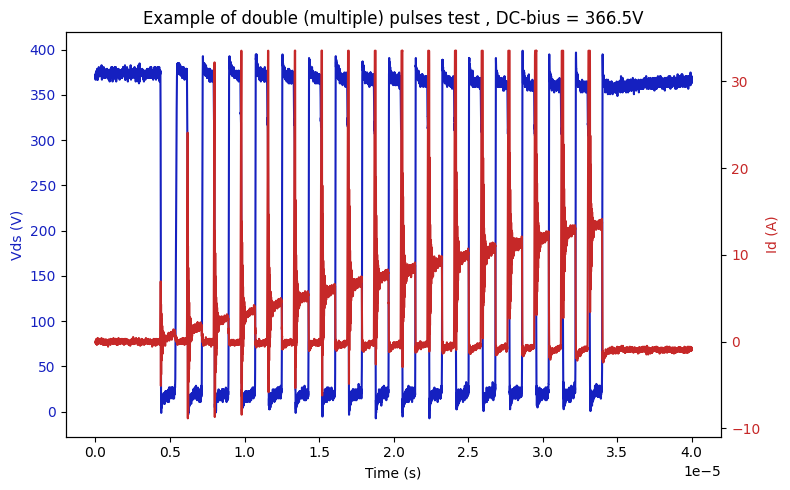

In [30]:


Ts = df.Ts.values[0]
vds = df.CH1.values * 100 - vds_thre  # x100 probe
iD = df.CH2.values - iD_thre          # x100 probe
iD = iD - iD[:500].mean()
time = df.time.values

# Create a single plot (1 row, 1 col)
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Vds on the primary y-axis (left)
color = bl#'tab:blue'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Vds (V)', color=bl)
ax1.plot(time, vds, color=color, label='Vds')
ax1.tick_params(axis='y', labelcolor=color)

# Create a secondary y-axis sharing the same x-axis
ax2 = ax1.twinx()  

# Plot iD on the secondary y-axis (right)
color = rd#'tab:red'
ax2.set_ylabel('Id (A)', color=rd)
ax2.plot(time, iD, color=color, label='iD')
ax2.tick_params(axis='y', labelcolor=color)

# Optional: Add a title and adjust layout
plt.title('Example of double (multiple) pulses test , DC-bius = 366.5V')
fig.tight_layout()
plt.show()

**Step 2 : Pre-processing the current**

The used current prob has a heigh pass filter effect, so below a pre-processing to remove this effect.

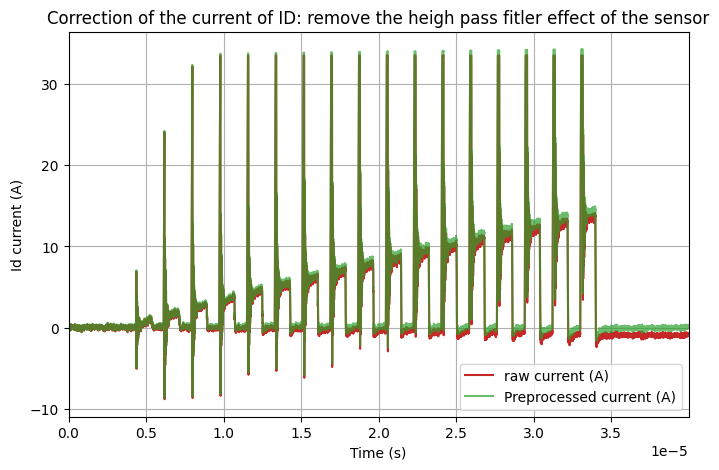

In [31]:
fig, ax1 = plt.subplots(figsize=(8, 5))

plt.plot(time, iD, c= rd, label = "raw current (A)")
#k= 7e-5
#iD2= iD + np.arange(0,len(iD))*k
#iD2[:100].mean(), iD2[-100:].mean()
def ID2_find(iD): 
    a = np.arange(len(iD))
    k = (iD[-100:].mean() - iD[:100].mean()) / (a[:100].mean() - a[-100:].mean())
    iD2 = iD + a * k
    return k, iD2 
k, iD2 = ID2_find(iD)

plt.plot(time, iD2, c= "C2", label = "Preprocessed current (A)", alpha =0.7)
plt.grid()

# Primary y-axis
p = vds*iD2
p = p-p[:500].mean()
E =np.cumsum(p)*Ts
plt.legend()
#plt.plot(t, p, color='C2')
#plt.show()
#plt.plot( E)
plt.title('Correction of the current of ID: remove the heigh pass fitler effect of the sensor')
plt.xlabel("Time (s)")
plt.ylabel('Id current (A)')
plt.xlim([time.min() , time.max()])
plt.show()

**Step 3: Detection of the rise/fall instants**

In [32]:
from math import *
arg=[0]
for i in range(10, len(vds)-10):
    if abs(vds[i+3]-vds[i-3])>20:
        if i-arg[-1]>100:
            arg.append(i) 
#print(len(arg))
#plt.plot(arg, len(arg)*[100], marker="x")
#plt.plot(vds)

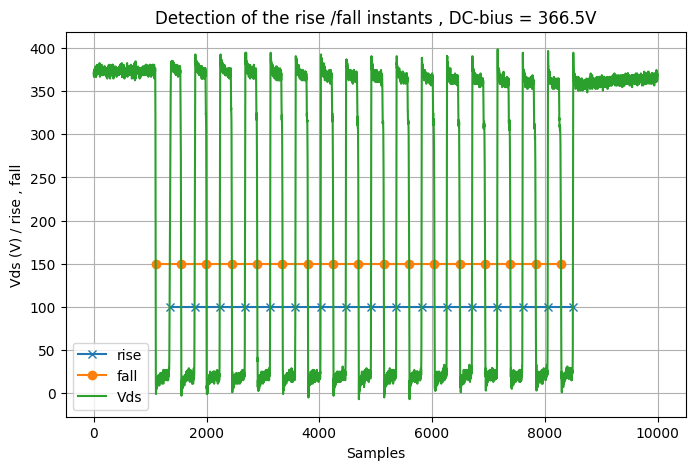

In [33]:
fig, ax1 = plt.subplots(figsize=(8, 5))

def trigger (sig , thresh= None, transition= "rise", marginI = 20):
    arr=[0]
    if thresh is None: 
        thresh = (sig.max()+sig.min())/2
    for i in range(1, len(sig)):
        if transition =="rise":
            if sig[i-1] <thresh and sig[i] >= thresh and i > arr[-1]+marginI:
                arr.append(i)
        elif sig[i-1] >thresh and sig[i] <= thresh and i > arr[-1]+marginI:
            arr.append(i)
    return arr[1:]
idx_rise = trigger (vds, transition= "rise")
idx_fall= trigger (vds, transition= "fall")
plt.plot(idx_rise, len(idx_rise)*[100], marker="x", label = "rise")
plt.plot(idx_fall, len(idx_fall)*[150], marker="o", label = "fall")
plt.plot(vds, label = "Vds")
plt.legend()
plt.grid()


plt.title('Detection of the rise /fall instants , DC-bius = 366.5V')
plt.xlabel("Samples")
plt.ylabel('Vds (V) / rise , fall')
#plt.xlim([time.min() , time.max()])
plt.show()

**Step 4: zoom around the switching instants**

In [34]:
Ts= df.Ts.iloc[0]

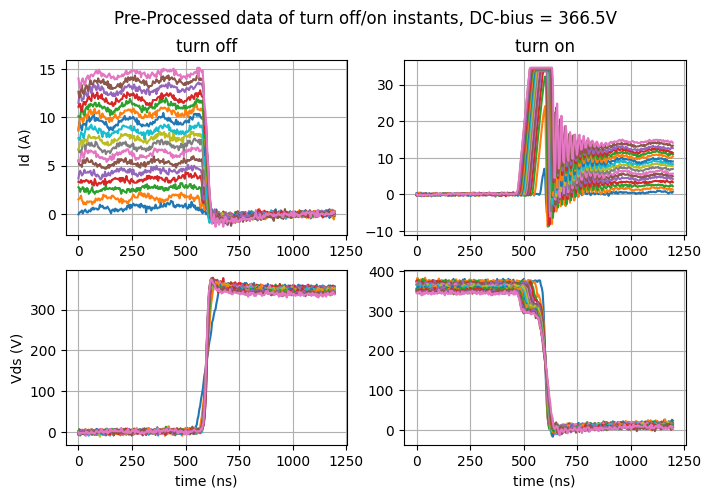

In [35]:
def EONEOFF (plot = True, pltshow = True): 
    idx_rise = trigger (vds, transition= "rise")
    idx_fall= trigger (vds, transition= "fall")
    if plot : 
        #fig , axs= plt.subplots(3,2,figsize=(8, 5))
        fig , axs= plt.subplots(2,2,figsize=(8, 5))
        #plt.subplots_adjust(wspace=0.5, hspace=0.5)
    di=150
    Eon={}
    Eoff={}
    deltaV={}
    k, iD2 = ID2_find(iD)
    #print(Ts)
    for i in idx_rise: 
        ### EOFF
        
        
        I1 = iD2[i-di-10:i-di].mean()
        
    
    
        I0 = iD2[i+di-50:i+di].mean()
        V0 = vds[i-di:i-di+50].mean()
        #V0=0
        #p=(vds[i-di:i+di]-V0)*(iD2[i-di:i+di]-I0)
        p=(vds[i-di:i+di])*(iD2[i-di:i+di])
        #print(i, di, i-di,i+di)
  
        indx = np.where(p>p.max()/2)[0]
        p2= p[indx[0]-20:indx[-1]+20]
        p2= p
        E= np.cumsum(p2)*Ts*1e6
    
        #Eoff[I1]=E
        t= np.arange(0,len(E)*Ts, Ts)*1e9
        #axs[2][0].plot(t[indx[0]-20:indx[-1]+20],E[indx[0]-20:indx[-1]+20])
        thresh=400
        p[p>thresh]
        #axs[2][0].plot(t[p>thresh],p[p>thresh])
        #if len(p[p>thresh])> 6:
        if 1: 
            E= np.sum(p)*Ts*1e6
            #E= np.sum(p[p>thresh])*Ts*1e6
            Eoff[I1]=E
            Ee = np.cumsum((vds[i-di:i+di]-V0)*(iD2[i-di:i+di]-I0))*Ts*1e6
            #axs[2][0].plot(t,Ee)

        if plot :
            y = p
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            #axs[2][0].plot(t,y)
            y=vds[i-di:i+di]-V0
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[1][0].plot(t,y)
            axs[0][0].set_title("turn off")
            y = iD2[i-di:i+di]-I0
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[0][0].plot(t,y)
        deltaV[I1]= vds[i-di:i+di].max()-vds[i-di:i+di][-20:].mean()
    for i in idx_fall: 
        # EON
        I1 = iD2[i+10:i+di*2+10].mean()
        I0 = iD2[i-di:i-di+50].mean()
    
        V0 = iD2[i+di-50:i+di].mean()
        #V0=0
    
        #p=(vds[i-di:i+di]-V0)*(iD2[i-di:i+di]-I0)
        p=(vds[i-di:i+di])*(iD2[i-di:i+di])
        indx = np.where(p>p.max()/2)[0]
        p2= p[indx[0]-20:indx[-1]+20]
        p2 =p
        #E= np.cumsum(p2)*Ts*1e6
        
        
        if plot :
            y = p
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            #axs[2][1].plot(t,y)
            y =vds[i-di:i+di]-V0
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[1][1].plot(t,y)
            axs[0][1].set_title("turn on")
            y=iD2[i-di:i+di]-I0
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[0][1].plot(t,y)
        #Eon[I1]=E
        #axs[2][1].plot(t,p)



        thresh=1000
        p[p>thresh]
        
        #if len(p[p>thresh])> 6:
        if 1: 
            E= np.sum(p)*Ts*1e6
            #E= np.sum(p[p>thresh])*Ts*1e6
            Eon[I1]=E
            #axs[2][1].plot(t[p>thresh],p[p>thresh])
            
        #axs[2][1].plot(t[indx[0]-20:indx[-1]+20],E[indx[0]-20:indx[-1]+20])
    if plot : 
        for ax in axs .flatten(): 
            ax.grid()
        axs[1][0].set_xlabel("time (ns)")
        axs[1][1].set_xlabel("time (ns)")
        axs[0][0].set_ylabel("Id (A)")
        axs[1][0].set_ylabel("Vds (V)")
        #axs[2][0].set_ylabel("Power (W)")
        fig.suptitle("Pre-Processed data of turn off/on instants, DC-bius = 366.5V")
    if pltshow:
        plt.show()
    else:
        plt.close(fig)   # <-- prevents showing but keeps fig so user can save it
    return Eon , Eoff, deltaV, fig
Eon , Eoff, deltaV , fig= EONEOFF (plot = True, pltshow = True)


**Step 5: Estimation of the Coss capacitor**

In [36]:
def EONEOFF (plot = True, pltshow = True): 
    idx_rise = trigger (vds, transition= "rise")
    idx_fall= trigger (vds, transition= "fall")
    if plot : 
        fig , axs= plt.subplots(3,2)
    di=150
    Eon={}
    Eoff={}
    deltaV={}
    k, iD2 = ID2_find(iD)
    #print(Ts)
    for i in idx_rise: 
        ### off
        
        
        I1 = iD2[i-di-10:i-di].mean()
        
    
    
        I0 = iD2[i+di-50:i+di].mean()
        V0 = iD2[i-di:i-di+50].mean()
        V0=0
        p=(vds[i-di:i+di]-V0)*(iD2[i-di:i+di]-I0)
        #print(i, di, i-di,i+di)
  
        indx = np.where(p>p.max()/2)[0]
        p2= p[indx[0]-20:indx[-1]+20]
        p2= p
        E= np.sum(p2)*Ts*1e6
    
        Eoff[I1]=E

        if plot :
            y = p
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[2][0].plot(t,y)
            y=vds[i-di:i+di]
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[1][0].plot(t,y)
            axs[0][0].set_title("turn off")
            y = iD2[i-di:i+di]-I0
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[0][0].plot(t,y)
        deltaV[I1]= vds[i-di:i+di].max()-vds[i-di:i+di][-20:].mean()
    for i in idx_fall: 
        I1 = iD2[i+10:i+di*2+10].mean()
        I0 = iD2[i-di:i-di+50].mean()
    
        V0 = iD2[i+di-50:i+di].mean()
        V0=0
    
        p=(vds[i-di:i+di]-V0)*(iD2[i-di:i+di]-I0)
        indx = np.where(p>p.max()/2)[0]
        p2= p[indx[0]-20:indx[-1]+20]
        p2 =p
        E= np.sum(p2)*Ts*1e6
        
        if plot :
            y = p
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[2][1].plot(t,y)
            y = vds[i-di:i+di]
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[1][1].plot(t,y)
            axs[0][1].set_title("turn on")
            y=iD2[i-di:i+di]-I0
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[0][1].plot(t,y)
        Eon[I1]=E
    if plot : 
        for ax in axs .flatten(): 
            ax.grid()
    if pltshow:
        plt.show()
    else:
        plt.close(fig)   # <-- prevents showing but keeps fig so user can save it
    return Eon , Eoff, deltaV, fig
#Eon , Eoff, deltaV , fig= EONEOFF (plot = False, pltshow = True)


In [37]:
from copy import copy 

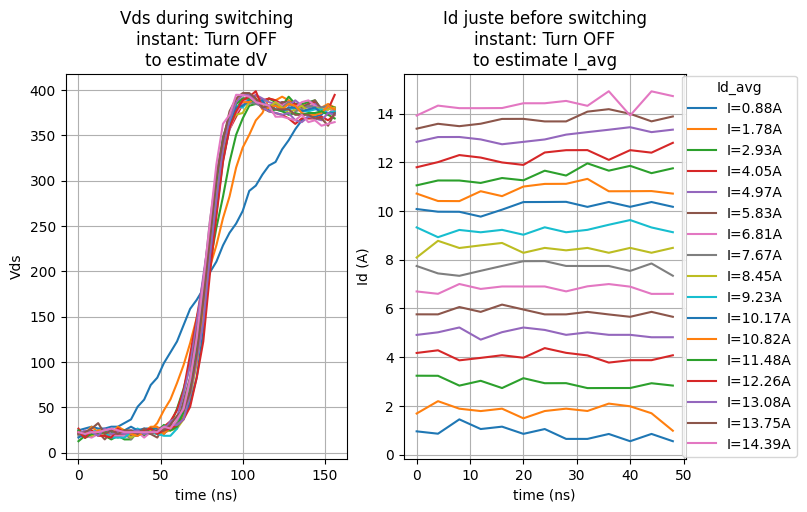

In [38]:
plot = True
pltshow = True
fig, axs = plt.subplots(1,2, figsize=(8,5))#, gridspec_kw={'wspace':0.5})
a=[]
dd={}

ddv=50
dd2={}

d_co_en={}
if 1: 
    idx_rise = trigger (vds, transition= "rise")
    idx_fall= trigger (vds, transition= "fall")

    di=150
    Eon={}
    Eoff={}
    deltaV={}
    k, iD2 = ID2_find(iD)
    #print(Ts)
    for i in idx_rise:# [::-1]: 
        ### off
        
        
        I1 = iD2[i-di-10:i-di].mean()
        
    
    
        I0 = iD2[i+di-50:i+di].mean()
        V0 = vds[i-di:i-di+50].mean()
        V0=0
        p=(vds[i-di:i+di]-V0)*(iD2[i-di:i+di]-I0)
        #print(i, di, i-di,i+di)
  
        indx = np.where(p>p.max()/2)[0]
        p2= p[indx[0]-20:indx[-1]+20]
        p2= p
        E= np.sum(p2)*Ts*1e6
    
        Eoff[I1]=E

        if plot :
            y = p
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            #axs[2][0].plot(t,y)
            di=20
            y=vds[i-di:i+di]
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            #DV = np.sum(vds[i-di:i+di])
            DV = y[-1]-y[0]
            #DV = y.max() - y.min()
            Q = np.sum(Ts*iD2[i-di:i+di])
            
            #xi=iD2[i-di:i+di]
            #yi= vds[i-di:i+di]
            #xi = xi-xi[-8:].mean()-I0
            #yi = yi-yi[:8].mean()

            mask = (y > (vds.min()+ddv)) & (y < (vds.max()-ddv))
            Y= y[mask]
            X = t[mask]
            I = iD2[i-di:i+di][mask]
            #dvdt= (Y[0 ]-Y[-1])/(X[0 ]-X[-1]) # i = c dv/dt
            DV = Y[0 ]-Y[-1]
            Q = np.sum(I*Ts)
            

            axs[0].plot(t,y)
            #axs[0][0].set_title("turn off")
            y = iD2[i-di:i-7]
            #axs[1].plot(iD2[i-di-100:i+di+100], label = f"I={y.mean():.2f}A")
            axs[1].plot(t[:len(y)],y, label = f"I={y.mean():.2f}A")
            Imean = y.mean()
            #Coss= Imean/dvdt
            #Coss= Q/DV

            DV = - (Y[0 ]-Y[-1])
            Q = np.sum(I*Ts)
            Co_tr= 1e12*Q/DV
            Co_en= 1e12*2*np.sum(Y*I*Ts)/DV**2

            #print(f"Imean = {Imean:.2f}A, Coss={Coss:.2f}nF")
            dd[Imean]=Co_tr
            d_co_en[Imean]= Co_en
            #dd2[Imean]=Q/DV
            a.append(y.mean()   )
            #t= np.arange(0,len(y)*Ts, Ts)*1e9
            #axs[0][0].plot(t,y)
        deltaV[I1]= vds[i-di:i+di].max()-vds[i-di:i+di][-20:].mean()

# axs[1].legend()
axs[1].legend(loc='center right', bbox_to_anchor=(1.42, 0.5), title = 'Id_avg')
i= 0
axs[i ].set_ylabel("Vds")
axs[i ].set_xlabel("time (ns)")
axs[i ].grid()
axs[i ].set_title("Vds during switching\ninstant: Turn OFF\nto estimate dV")

i= 1
axs[i ].set_ylabel("Id (A)")
axs[i ].set_xlabel("time (ns)")
axs[i ].grid()
axs[i ].set_title("Id juste before switching\ninstant: Turn OFF\nto estimate I_avg")
plt.show()

Formulas to calculate the mosfet capacitors:

Time related capacitance 

$i = C \frac{dv}{dt}$

$C_o(tr)= \frac{\int i \cdot dt}{\int dv} = \frac{Q}{\Delta V}$


Energy-related capacitance

$E = \int v \cdot i \cdot dt$

$C_{o(er)} = \frac{2E}{\Delta V^2}$

In [39]:
_="""xi = xi-xi[-8:].mean()
yi = yi-yi[:8].mean()

plt.plot(X,Y*0.01)
plt.plot(X,I)
plt.grid()"""

In [40]:
_="""DV = - (Y[0 ]-Y[-1])
Q = np.sum(I*Ts)
Coss= 1e12*Q/DV
Coss, len(Y), len(X), len(I)"""

In [41]:
_ = '''S=(pd.Series(dd))

S.plot(marker = "o", figsize=(8,5), label= "Estimation")

plt.title("Estimation of the Co(tr) of the mosfet, DC-bius = 366.5V")
plt.xlabel("Id_avg (A)")
plt.ylabel('Co-tr (pF)')
#plt.xlim([time.min() , time.max()])
plt.grid()
plt.plot(S.index, S*0+1599, label ="Co(tr) datasheet PW60R037P7")
plt.legend()
plt.show()'''

In [42]:
_='''S=(pd.Series(dd))

S.plot(marker = "o", figsize=(8,5), label= "Estimation")

plt.title("Estimation of the Co(tr) of the mosfet, DC-bius = 366.5V")
plt.xlabel("Id_avg (A)")
plt.ylabel('Co-tr (pF)')
#plt.xlim([time.min() , time.max()])
plt.grid()
plt.plot(S.index, S*0+1599, label ="Co(tr) datasheet PW60R037P7")
plt.legend()
plt.show()'''

In [43]:
_='''S1=(pd.Series(dd))
S2=(pd.Series(d_co_en))
S1-S2'''

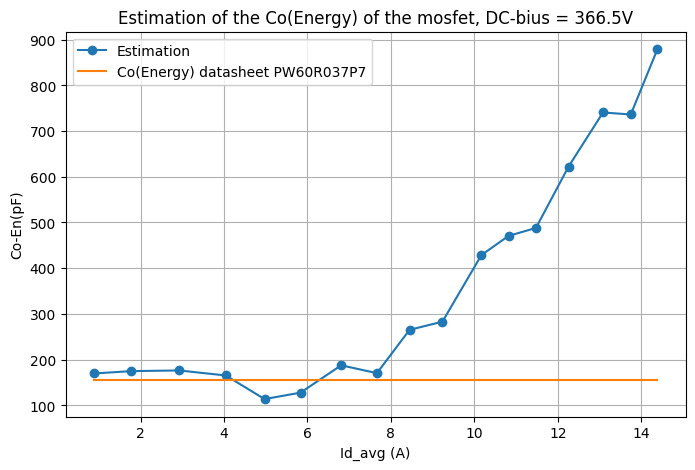

In [44]:
#(1e12*pd.Series(d_co_en)).plot(marker = "o", figsize=(8,5))

S=(pd.Series(d_co_en))

S.plot(marker = "o", figsize=(8,5), label= "Estimation")

plt.title("Estimation of the Co(Energy) of the mosfet, DC-bius = 366.5V")
plt.xlabel("Id_avg (A)")
plt.ylabel('Co-En(pF)')
#plt.xlim([time.min() , time.max()])
plt.grid()
plt.plot(S.index, S*0+156, label ="Co(Energy) datasheet PW60R037P7")
plt.legend()
plt.show()

Why the estimation of Co-Energy is good at low corrent, and bad in heigh current: 
$$E_{total} = E_{oss} + E_{switching\_loss}$$

In low current loss energy is low so almost the all measured energy is the stored energy in the mosfet capacitor, but in heigh current a part of energy is converted to heat.

To reproduce this phynomina, I propose the simple simulation below: 

In [45]:
fig_counter=  show_figure_pair_with_captions(
fig_counter, 
img1="./figs/SimDPT.png", 
caption1="Simple simulation of the turning off instant of SPA11N60C3", 
first_part_path="", 
width="100%"
)

Lest's calculating the sw-enrgy and the coresponding capacitor using pre-processing of the raw data using python 

In [46]:
dfs=pd.read_csv("07_sim/simDPT.txt", sep="\t")


Text(0.5, 1.0, 'Switching power = Id * Vds (W)')

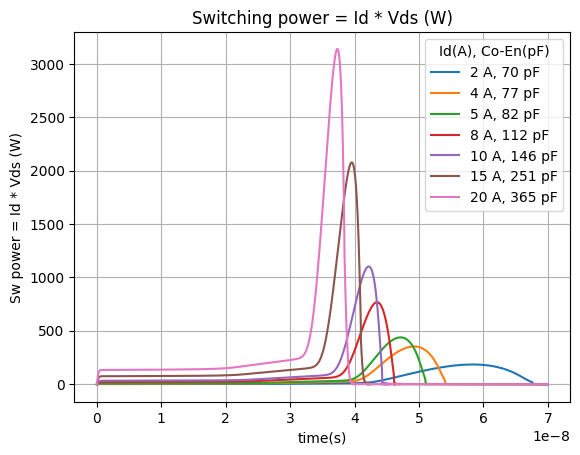

In [47]:
ids = dfs['time'].astype(str).str.extract(r'Id=(\d+)').ffill()[0].astype(int)
df_dict = {i: d[~d['time'].astype(str).str.contains("Step")].apply(pd.to_numeric) for i, d in dfs.groupby(ids)}
dic={}
for k, v in df_dict.items():
    t=v.time.values
    p = v['V(m)*Id(M1)'].values
    E= np.trapezoid(y=p, x=t)
    DV=300
    Coen= 1e12*(2*E/DV**2)
    dic[float(k)]=Coen
    plt.plot(t, p, label = f"{k} A, {Coen:.0f} pF")
plt.legend(title = "Id(A), Co-En(pF)")
plt.grid()
plt.xlabel("Id_init (A)")
plt.xlabel("time(s)")
plt.ylabel("Sw power = Id * Vds (W)")
plt.title("Switching power = Id * Vds (W)")

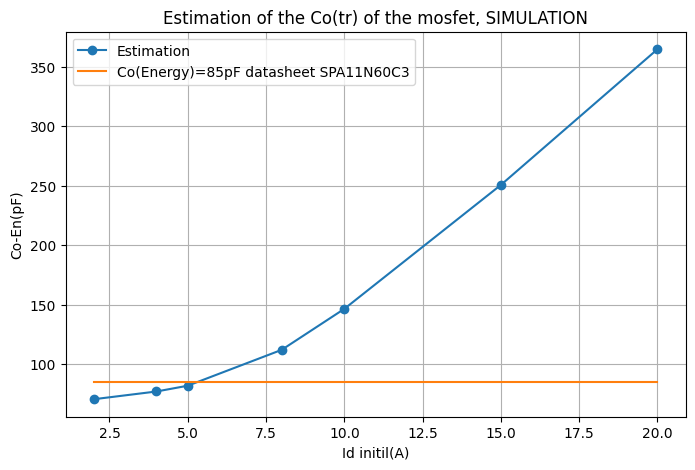

In [48]:
#(1e12*pd.Series(d_co_en)).plot(marker = "o", figsize=(8,5))

S=(pd.Series(dic))

S.plot(marker = "o", figsize=(8,5), label= "Estimation")

plt.title("Estimation of the Co(tr) of the mosfet, SIMULATION")
plt.xlabel("Id initil(A)")
plt.ylabel('Co-En(pF)')
#plt.xlim([time.min() , time.max()])
plt.grid()
plt.plot(S.index, S*0+85, label ="Co(Energy)=85pF datasheet SPA11N60C3")
plt.legend()
plt.show()

So , we can see the same behaviour our measurement

In [49]:
import pandas as pd

# 1. Load the data
df = pd.read_csv("07_sim/simDPT.txt", sep="\t")

# 2. Filter out the text rows
# This keeps only rows where the 'time' column does NOT contain the word "Step"
df_clean = df[~df['time'].astype(str).str.contains("Step")].copy()

# 3. Force the columns to be actual numbers (floats)
df_clean['time'] = pd.to_numeric(df_clean['time'], errors='coerce')
df_clean['V(m)*Id(M1)'] = pd.to_numeric(df_clean['V(m)*Id(M1)'], errors='coerce')

# 4. NOW you can sort safely!
df_sorted = df_clean.sort_values(by='time', ascending=True).reset_index(drop=True)

print(df_sorted.head())

   time  V(m)*Id(M1)
0   0.0         -0.0
1   0.0         -0.0
2   0.0         -0.0
3   0.0         -0.0
4   0.0         -0.0


In [50]:
Eon , Eoff, deltaV , fig= EONEOFF (plot = True, pltshow = False)
fig.savefig("figs/test.png")

In [51]:
# without dead time 
#E0= Vmos*I*T
# with dead time 
#E1= Vmos*I*(T-2*dead)+VF*I*2dead=Vmos*I*T -2*Vmos*I*dead+VF*I*2dead
#dE/E0= 2*(dead/T)*(VF-Vmos)/Vmos
Vmos = 0.2
T=10e3 # ns
VF=1
for dead in (50,100,150,200,300):
    pass
    #print("# dead ns", dead, "dE/E0 % = ",100*2*(dead/T)*(VF-Vmos)/Vmos)
# dead ns 50 dE/E0 % =  0.04
# dead ns 100 dE/E0 % =  0.08
# dead ns 150 dE/E0 % =  0.12
# dead ns 200 dE/E0 % =  0.16
# dead ns 300 dE/E0 % =  0.24

In [52]:
_="""-pd.Series(Eon)).plot(label = "Eon",marker="x")
plt.legend()
plt.show()
s=pd.Series(Eoff)
s=s[s.index>3]
s.plot(label = "Eoff",marker="x")
plt.legend()
"""

### Rg impact

In this section, we will change gate resistor, and check the impact in the loss energy.

We calculating the Eon just for information, since we are in ZVS, Eon is very low, and the calculated Eon is compatible with no ZVS function.

In the PCB we mount 3 resistors in parallel for Rg, 3 Ω , 5 Ω and 10 Ω with a jumper, so it will be easy to change Rg using this value, or any combinason of parallel configuration like  3 Ω // 5 Ω  = 1.875 Ω  and 3 Ω // 10 Ω  =2.30 Ω (see the photo below)

Just for information, we broked the mosfet during this test @400V, so we recommande to no make SW-ON.

In [53]:

fig_counter=show_figure_pair_with_captions(fig_counter, 
                               img1="jumper.png", 
                               caption1="The Jumper used to select Rg", 
                               img2="jumper2.png", 
                               caption2="Jumper in the PCB with the 3 resostors (3D)", 
                               first_part_path="figs/")



In [54]:
l = """10 ohm 
2025-11-29_15-40-48-127
5 ohm
2025-11-29_15-41-49-332
3 ohm
2025-11-29_15-42-24-226
3 ohm V2
2025-11-29_15-51-14-933
3//5=1.87 ohm 
2025-11-29_16-23-05-938
10//3 =2.3 ohm 
2025-11-29_16-25-13-741""".replace(" ", "").split("\n")
names = l[1::2]
labels=l[0::2]
names = [r"./02_double_pulse/366.5V_V3/" + x for x in names]
#print(names), print(labels)

In [55]:
#list={}
dic  = {}
for i in range(len(names)):
    data ={}
    path  = names[i]+".csv"
    label = labels[i]
    #print(path, label)
    df = pd.read_csv(path)
    Ts = df.Ts.values[0]
    vds = df.CH1.values*100 -vds_thre # x100 probe
    iD =  df.CH2.values-iD_thre # x100 probe
    iD = iD -iD[:500].mean()
    
    

    Eon , Eoff, deltaV , fig= EONEOFF (plot = True, pltshow = False)
    fig.savefig(f"figs/{label.replace("/", "_")}.png")
  
      
        
    #plt.show()  
    data["Eon"]=Eon
    #(-pd.Series(Eon)).plot(label = "Eon",marker="x")
    #s.plot(label = "Eoff",marker="x")
    data["Eoff"]= Eoff
    data["deltaV"]= deltaV
    #plt.legend()
    #plt.show()
    dic[label]= data

In [56]:
#dic

In [57]:
#dic.keys()

In [58]:
#dic['10ohm'].keys()

We followed the same steps as shown in the example above to calculate the Eon/Eoff of each Rg configuration

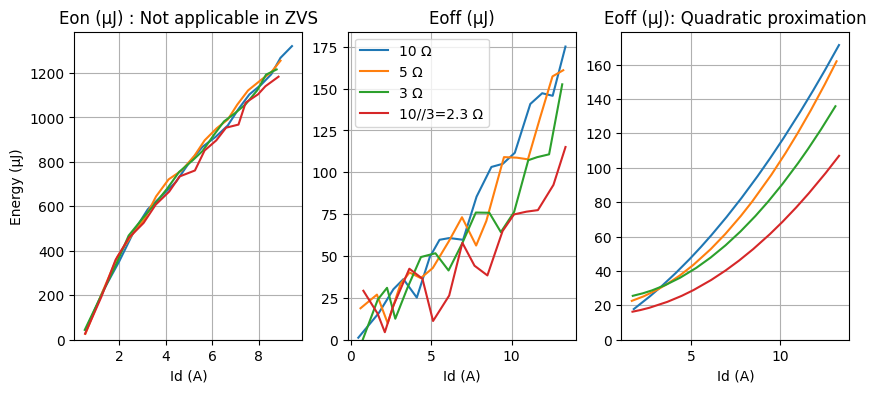

In [59]:
fig, axs = plt.subplots(1,3, figsize=(10,4)
# gridspec_kw={'wspace':0.5#, 'hspace': 1.}
                       )
for kk, v in dic.items():
    if kk in ['3//5=1.87ohm', '3ohmV2']:
        continue
        #pass
    Eon = v["Eon"]
    #Eon = Eon[Eon.index>1]
    Splot = pd.Series(Eon)

    Splot.plot(ax = axs[0], label = kk)
    Eoff = v["Eoff"]
    #Eon = Eon[Eon.index>1]
    Splot = pd.Series(Eoff)
    
    Splot.plot(ax = axs[1], label = kk.replace("ohm", " Ω"))
    #Splot = pd.Series(Eon)
    i=1
    x= list(Splot.index)[i:]
    y = Splot.values[i:]
    coef = np.polyfit(x, y,2)
    y_pred = np.polyval(coef, x)
    axs[2].plot(x, y_pred, label = kk.replace("ohm", " Ω"))

axs[0].set_title("Eon (µJ) : Not applicable in ZVS")
axs[1].set_title("Eoff (µJ)")
axs[2].set_title("Eoff (µJ): Quadratic proximation")

axs[0].set_ylabel("Energy (µJ)")
for ax in axs: 
    ax.set_xlabel("Id (A)")
    ax.grid()
    ax.set_ylim([0, None ])
    

#axs[0].legend()
axs[1].legend()
plt.savefig("figs/res.png")

**Rg = 3 Ω** is a good compromise between reducing the switching energy and avoiding oscillation, we will conserve this value for this project

## Gate current
n this test, we measured the gate current using TCP202, so a small loop wire is added to the current path to insert the current probe (inductance)

The test was done in low voltage condition:
* Vin = 48.03V
* Vout = 8.03V
* Freq = 150kHz (Max freq of the DC-DC)

This test is done with the old primary mosfet (before updating the BOM)

In [60]:



fig_counter=show_figure_pair_with_captions(fig_counter, 
                               img1="./05_Driver_current/2025-12-31_10-15-14-895.png", 
                               caption1="Primary-Low side gate current/voltage", 
                               first_part_path="",width = "75%")



In [61]:
#df= pd.read_csv("2025-12-31_10-02-29-641.csv")
df= pd.read_csv("./05_Driver_current/2025-12-31_10-00-11-480.csv")


In [62]:
import scipy

**Pre-Processing of the oscilloscope raw data**

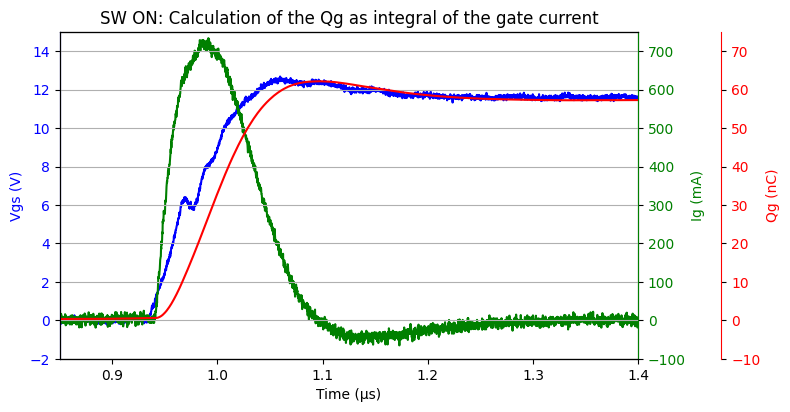

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate

# --- Data ---
Ts = df.Ts.values[0]
ig = -(df.CH2.values - df.CH2.values[:200].mean())
vgs = df.CH4.values * 10 - (df.CH4.values * 10)[:200].mean()
qg = scipy.integrate.cumulative_trapezoid(y=ig, dx=Ts, initial=0)
time = np.arange(0, Ts * len(vgs), Ts)

# --- 3 Y-Axes Plot ---
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2, ax3 = ax1.twinx(), ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))

# Trace 1 (Left)
ax1.plot(1e6*time, vgs, "b-")
ax1.set_xlabel("Time (µs)")
ax1.set_ylabel("Vgs (V)", color="b")
ax1.tick_params(axis="y", labelcolor="b")
ax1.spines["left"].set_color("b")
ax1.set_ylim([-2,15])

# Trace 2 (Right)
ax2.plot(1e6*time,  1000*ig, "g-")
ax2.set_ylabel("Ig (mA)", color="g")
ax2.tick_params(axis="y", labelcolor="g")
ax2.spines["right"].set_color("g")
ax2.set_ylim([-100,750])

# Trace 3 (Far Right)
ax3.plot(1e6*time,  1e9*qg, "r-")
ax3.set_ylabel("Qg (nC)", color="r")
ax3.tick_params(axis="y", labelcolor="r")
ax3.spines["right"].set_color("r")
ax3.set_ylim([-10,75])
plt.tight_layout()
plt.grid()
plt.xlim([0.85,1.4])
plt.title('SW ON: Calculation of the Qg as integral of the gate current') 
plt.show()

In [64]:
vgson = copy(vgs)
igon= copy(ig)
qgon = copy(qg)

**MOSFET: Miller plateau**

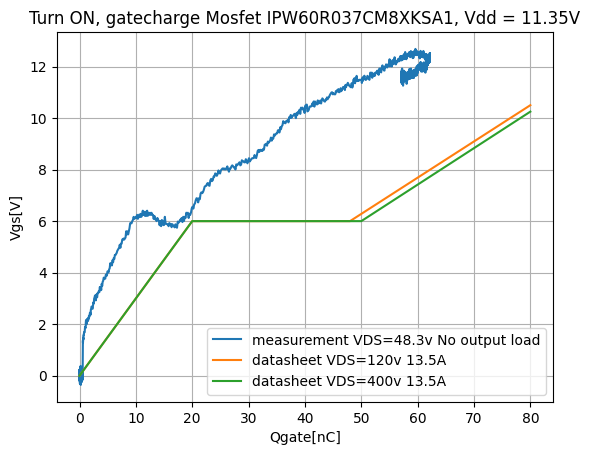

In [65]:
plt.plot(qgon*1e9,vgson, label= "measurement VDS=48.3v No output load")



Qn120 = [0, 20, 48,80]
Vn120 = [0, 6 , 6, 10.5]
plt.plot(Qn120, Vn120, label= "datasheet VDS=120v 13.5A")


Qn400 = [0, 20, 50,80]
Vn400 = [0, 6 , 6, 10.25]
plt.plot(Qn400, Vn400, label= "datasheet VDS=400v 13.5A")
#plt.plot([0,88],[vdd, vdd], label= "Vdd", linestyle = "--")
plt.legend()
plt.grid()
plt.xlabel("Qgate[nC]")
plt.ylabel("Vgs[V]")
plt.title("Turn ON, gatecharge Mosfet IPW60R037CM8XKSA1, Vdd = 11.35V")
plt.show()

The Miller plateau is not very pronounced because the SW-ON is in ZVS mode and at low voltage.

## Secondary driver

**Reminder of the secondary-side synchronous rectifier driver**

the master ic : NCP43080DDR2G

In [66]:
fig_counter=show_figure_pair_with_captions(fig_counter, 
                               img1="secdrv.png", 
                               caption1="The driver NCP43080DDR2G", 
                               img2="jumpers.png", 
                               caption2="Jumper to shose Rg from 0, 1, 3 ohm", 
                               first_part_path="./figs/")

The controller presents a limitation, its conduction time depends heavily on the load; see the test below.

**Test conditions**: 
* Vin = 393.5 v
* Vout = 48.11 v

Oscilloscope: 
* CH1 : Vds low side primary x 100
* CH2 : Vgs low side secondary: driver output
* CH4 : Vds low side secondary x 10

In [67]:
files = """no load 
2026-02-14_13-56-32-214
load1  52.1 ohm
2026-02-14_13-58-48-201
load2 36 ohm
2026-02-14_14-00-43-431
load3 3 24.5 ohm
2026-02-14_14-01-25-664
load4 12.8 ohm
2026-02-14_14-07-22-440
load5 9.2 ohm
2026-02-14_14-09-33-703""".split('\n')

names = files[::2]
files = files[1::2]
for i in range(0,len(files),2):
    fig_counter=show_figure_pair_with_captions(fig_counter, 
                                   img1=files[i]+".png", 
                                   caption1=names[i], 
                                   img2=files[i+1]+".png", 
                                   caption2=names[i+1], 
                                   first_part_path="./06_DriverOutput/")



    

Grouping of all test data : 

In [68]:
fig_counter=show_figure_pair_with_captions(fig_counter, 
                               img1="./06_DriverOutput/SR_Performance.png", 
                               caption1="PreProcessing of the test results", 
                               first_part_path="")



## Annexes 

### Carat of the big Lm 

In [69]:


fig_counter=show_figure_pair_with_captions(fig_counter, 
                               img1="2025-11-15_08-57-09-014.png", 
                               caption1="Current", 
                               img2="2025-11-15_08-58-22-370.png", 
                               caption2="Voltage", 
                               first_part_path="./08_old/Double_Pulse_full_code/DPT_97V_caract_Lm_transfo_Nissan/")



We used the same double-pulse setup to characterize the large 16-turn inductor.

See the oscilloscope above (CH1 is and isolated x 100 prob)

In [70]:
%%render 
N = 16 # turns 
Delta_I = 1.82# A
Delta_t = 7.36# µs
V_L = 928 *100 *1e-3 # V


<IPython.core.display.Latex object>

Since $ V_L = L \frac{di}{dt}$

In [71]:
%%render 
L = V_L * (Delta_t/Delta_I) # µH
AL = 1e3 * L/N**2 # nH/turn2

<IPython.core.display.Latex object>

### Quick prototyping of rogowski coil

During this project, we experimented with several methods to produce a prototype of a Rogowski coil, The idea is to prototype a very simple Rogowski coil and perform the integration via signal preprocessing.

the produced signal is:  
$e = k .di/dt$

So a preprocessing integral is necessary and an empirical estimation of the coed k

Below some image of the prototyped coils:

In [72]:
import glob

images = glob.glob("./figs/rogowskiCoil/*.jpg")
images.sort()
for i in range(0,len(images)-1,2):

    
    fig_counter=show_figure_pair_with_captions(fig_counter, 
                                   img1=images[i], 
                                   caption1="", 
                                   img2=images[i+1], 
                                   caption2="", 
                                   first_part_path="")




**The proprocessing**

In [73]:
    fig_counter=show_figure_pair_with_captions(fig_counter, 
                                   img1="./08_old/Double_Pulse_full_code/DPT_320V/rogowski_coil/2025-11-15_22-39-30-937.png", 
                                   caption1="Example of measurement", 
                                   first_part_path="",width="75%")

* CH3 is TCP202 360µH current
* CH4 Rogowski coil voltage (therminal 50ohm)

In [74]:
df= pd.read_csv("./08_old/Double_Pulse_full_code/DPT_320V/rogowski_coil/2025-11-15_22-39-30-937.csv")

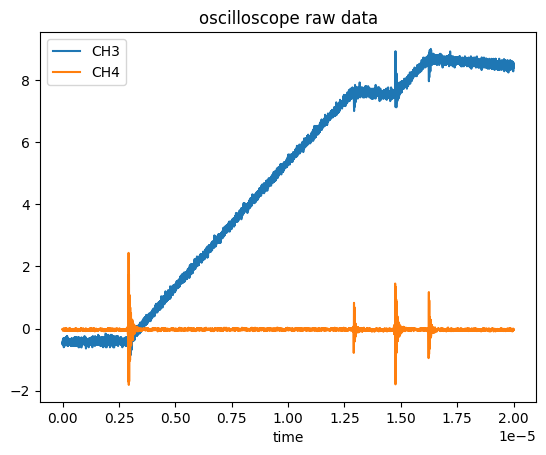

In [75]:
df.plot(x = "time", y=["CH3", "CH4"])
plt.title("oscilloscope raw data")
plt.show()

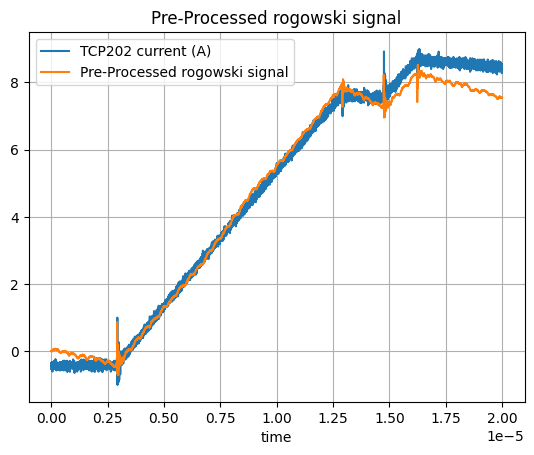

In [18]:
df= pd.read_csv("./08_old/Double_Pulse_full_code/DPT_320V/rogowski_coil/2025-11-15_22-39-30-937.csv")

CH4 = df.CH4.values
    
v = CH4-CH4[:300].mean()
Ts= df.Ts.iloc[0]
intV = np.cumsum(v)*Ts
df.plot(x= "time", y="CH3", label = "TCP202 current (A)")
#(pd.Series(intV)*0.6e8).plot()
plt.plot(df.time, pd.Series(intV)*1.15e8, label = "Pre-Processed rogowski signal")
plt.legend()
plt.grid()
plt.title("Pre-Processed rogowski signal")
plt.show()

Preprocessed rogowski signal is very good to detect fast change of the current but bad in low frequency area

### Double pulse code STM32f103

**Simple double pulse code**

```C
#include "stm32f1xx.h"

#define CPU_FREQ 72000000UL
#define PA9_SET  (1u << 9)
#define PA9_RST  (1u << (9 + 16))
#define PA9_BIT  (1u << 9)

static inline void dwt_start(void) {
  CoreDebug->DEMCR |= CoreDebug_DEMCR_TRCENA_Msk;
  DWT->CYCCNT = 0;
  DWT->CTRL |= DWT_CTRL_CYCCNTENA_Msk;
}


void setup(void) {
  // Enable GPIOA clock
  RCC->APB2ENR |= RCC_APB2ENR_IOPAEN;

  // PA9 = General purpose push‑pull output, 50 MHz (CRH bits [7:4])
  GPIOA->CRH &= ~(0xFu << 4);
  GPIOA->CRH |=  (0x3u << 4);   // MODE9=11 (50MHz), CNF9=00 (GP PP)

  // Ensure USART1 doesn't grab PA9 (we don't enable it)
  RCC->APB2ENR &= ~RCC_APB2ENR_USART1EN;

  dwt_start();

  // Quick self-check: force LOW and verify ODR reflects it
  GPIOA->BSRR = PA9_RST;
  if (GPIOA->ODR & PA9_BIT) { for (;;){ /* trap if config failed */ } }
}

void loop(void) {
  uint32_t ton1  = 2; // us
  uint32_t toff1 = 1; // us
  uint32_t ton2  = 1; // us
  uint32_t toff2 = 1; // us

  GPIOA->BSRR = PA9_SET; 
  delayMicroseconds(ton1); 

  GPIOA->BSRR = PA9_RST; 
  delayMicroseconds(toff1);
   
  GPIOA->BSRR = PA9_SET; 
  delayMicroseconds(ton2);

  GPIOA->BSRR = PA9_RST;
  delayMicroseconds(toff2);
}
```

**Train of double pulse**

```C
#include "stm32f1xx.h"

// --- PA9 macros ---
#define PA9_SET   (1u << 9)
#define PA9_RST   (1u << (9 + 16))

// --- PB14 macros ---
#define PB14_SET  (1u << 14)
#define PB14_RST  (1u << (14 + 16))


#define _Ena_drv PB10
#define _Dis_drv PB12

void setup() {
// Force PB12 HIGH in output data register BEFORE pinMode changes the mode
// digitalWrite(_Dis_drv, HIGH);     // preload ODR = 1 (float high in open-drain mode)
digitalWrite(_Dis_drv, LOW); 
pinMode(_Dis_drv, OUTPUT_OPEN_DRAIN);
digitalWrite(_Dis_drv, LOW); // redundancy
digitalWrite( _Ena_drv, HIGH); 
pinMode(_Dis_drv, OUTPUT);
digitalWrite( _Ena_drv, HIGH); 




/////// PA9 & PB14 as Fast output ///////////
  // Enable GPIOA + GPIOB clocks
  RCC->APB2ENR |= RCC_APB2ENR_IOPAEN | RCC_APB2ENR_IOPBEN;

  // --- PA9 = 50 MHz push-pull output ---
  GPIOA->CRH &= ~(0xF << 4);   // clear config bits
  GPIOA->CRH |=  (0x3 << 4);   // MODE9=11 (50MHz), CNF9=00
  GPIOA->BSRR = PA9_RST;       // start LOW

  // --- PB14 = 50 MHz push-pull output ---
  GPIOB->CRH &= ~(0xF << 24);  // PB14 config bits
  GPIOB->CRH |=  (0x3 << 24);  // MODE14=11, CNF14=00
  GPIOB->BSRR = PB14_RST;      // start LOW



}




__attribute__((always_inline)) 
static inline void delayNs(uint32_t tns)
{
    /*
    target => oscilo
    6000ns => 5986ns 
    1000ns => 985.3ns
    */

    uint32_t iterations = (tns * 72) / (6.08*1000);

    for (uint32_t i = 0; i < iterations; i++) {
        __asm__ __volatile__("nop" ::: "memory");
    }
}


void loop() {


//////////// ENABLE DRIVER 
delayMicroseconds(10); 
digitalWrite(_Dis_drv, HIGH); // redundancy
digitalWrite( _Ena_drv, LOW); 
delayMicroseconds(10); 
digitalWrite( _Ena_drv, HIGH); 


/////////// double pulse waveform on / off / on /off

  uint32_t ton  = 1000; // ns
  uint32_t toff = 800; // ns
  uint32_t N  = 17; // n of pulses

  for (int i = 0; i<N; i++){
  GPIOA->BSRR = PA9_SET; 
  delayNs(ton);
  GPIOA->BSRR = PA9_RST; 
  delayNs(toff);
  }


  while(1); 


}
```